In [1]:
! pip install numpy pandas matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

In [3]:
data = pd.read_csv("Experience-Salary.csv")

print(data.head())

   exp(in months)  salary(in thousands)
0           18.29                 16.52
1           17.02                 11.67
2           26.34                 23.17
3           19.11                 20.88
4           27.74                 23.17


In [4]:
threshold = data['salary(in thousands)'].median()

data['Label'] = data['salary(in thousands)'].apply(lambda x: 1 if x >= threshold else 0)

In [5]:
X = data[['exp(in months)']].values
y = data['Label'].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = SVC(kernel='linear', C=10, gamma=0.1)
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [9]:
y_pred = model.predict(X_test)

In [10]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.825

Confusion Matrix:
 [[79 16]
 [19 86]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82        95
           1       0.84      0.82      0.83       105

    accuracy                           0.82       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.83      0.82      0.83       200



In [11]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

# Perform 5-fold cross-validation
scores = cross_val_score(pipeline, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Cross-validation scores: [0.78  0.825 0.815 0.875 0.785]
Mean accuracy: 0.8160000000000001
Standard deviation: 0.034117444218463945


In [12]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.815
Test Accuracy: 0.825


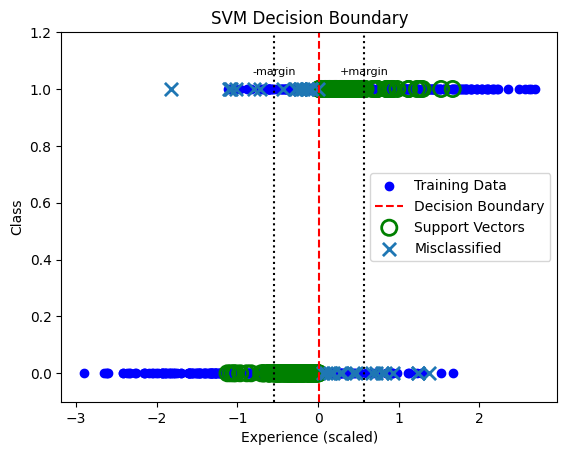

In [13]:
# Extract scalar values
w = model.coef_[0][0]
b = model.intercept_[0]

boundary = -b / w
margin = 1 / abs(w)

# Support vectors
sv = model.support_vectors_
sv_pred = model.predict(sv)

# Plot
plt.scatter(X_train[:, 0], y_train, color='blue', label='Training Data')

# Decision boundary + margins
plt.axvline(x=boundary, color='red', linestyle='--', label='Decision Boundary')
plt.axvline(x=boundary + margin, color='black', linestyle=':')
plt.axvline(x=boundary - margin, color='black', linestyle=':')

# Support vectors
plt.scatter(sv[:, 0], sv_pred,
            s=120, facecolors='none', edgecolors='green',
            linewidth=2, label='Support Vectors')

# Misclassified points
y_pred_test = model.predict(X_test)
mis = X_test[y_test != y_pred_test]
mis_y = y_test[y_test != y_pred_test]

plt.scatter(mis[:, 0], mis_y, marker='x', s=90, linewidths=2, label='Misclassified')

# Annotation
plt.text(boundary + margin, 1.05, '+margin', ha='center', fontsize=8)
plt.text(boundary - margin, 1.05, '-margin', ha='center', fontsize=8)
plt.ylim(-0.1, 1.2)
plt.xlabel("Experience (scaled)")
plt.ylabel("Class")
plt.title("SVM Decision Boundary")
plt.legend(loc='best', frameon=True)
plt.show()